# 최종 개선 버전: 변동성 반영 독립변수 예측

## 🎯 핵심 개선사항
1. **Prophet**: 추세 + 계절성 + 충격(코로나 등) 자동 감지
2. **Auto-ARIMA**: 자기회귀 모델로 과거값 패턴 학습
3. **RF + Lag**: 비선형 패턴 + 과거 12개월 정보
4. **변수 특성별 최적 방법 자동 선택**

## 📊 예측 전략
```
높은 변동성 (소비자심리, 항공, 뉴스) → Prophet
안정적 추세 (인구, 물가지수) → Auto-ARIMA  
계절성 + 비선형 (출입국, 관광) → RF + Lag
상호 의존 (교통수송) → VAR
```

In [36]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm

# 시계열 모델
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR
try:
    from pmdarima import auto_arima
except:
    print("⚠️ pmdarima 설치 필요: pip install pmdarima")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

# 경로 설정
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == 'code':
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

RAW_DATA_PATH = PROJECT_DIR / 'raw_data'
PROCESSED_DATA_PATH = PROJECT_DIR / 'processed_data'
RESULT_PATH = PROJECT_DIR / 'result'
RESULT_PATH.mkdir(exist_ok=True)

print(f"✅ 경로 설정 완료:\n   Processed: {PROCESSED_DATA_PATH}")

⚠️ pmdarima 설치 필요: pip install pmdarima
✅ 경로 설정 완료:
   Processed: /mnt/c/Users/Admin/PycharmProjects/Demand-Forecasting-Dive/processed_data


## Phase 0: 데이터 로드 및 변수 그룹 정의

In [37]:
# 데이터 로드
df_merged = pd.read_csv(PROCESSED_DATA_PATH / 'df_hs.csv')
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged = df_merged.sort_values('Date').reset_index(drop=True)

print(f"✅ 데이터 로드 완료: {df_merged.shape}")
print(f"   기간: {df_merged['Date'].min()} ~ {df_merged['Date'].max()}")

# 기본 시간 변수 추가
def add_time_features(df):
    df = df.copy()
    kr_holidays = holidays.KR()
    df['is_holiday'] = df['Date'].apply(lambda x: x in kr_holidays).astype(int)
    df['weekday'] = df['Date'].dt.weekday
    df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
    df['TimeIndex'] = (df['Date'].dt.year - df['Date'].dt.year.min()) * 12 + df['Date'].dt.month
    df['Month_sin'] = np.sin(2 * np.pi * df['Date'].dt.month / 12)
    df['Month_cos'] = np.cos(2 * np.pi * df['Date'].dt.month / 12)
    df['Quarter'] = df['Date'].dt.quarter
    return df

df_merged = add_time_features(df_merged)
time_features = ['TimeIndex', 'Month_sin', 'Month_cos', 'Quarter', 'is_weekend', 'is_holiday']

# Train/Test 분할
train_mask = df_merged['Date'] < '2024-04-01'
test_mask = df_merged['Date'] >= '2024-04-01'
df_train = df_merged[train_mask].copy()
df_test = df_merged[test_mask].copy()

print(f"\nTrain: {df_train['Date'].min()} ~ {df_train['Date'].max()} ({len(df_train)}개월)")
print(f"Test: {df_test['Date'].min()} ~ {df_test['Date'].max()} ({len(df_test)}개월)")

✅ 데이터 로드 완료: (132, 116)
   기간: 2015-01-01 00:00:00 ~ 2025-12-01 00:00:00

Train: 2015-01-01 00:00:00 ~ 2024-03-01 00:00:00 (111개월)
Test: 2024-04-01 00:00:00 ~ 2025-12-01 00:00:00 (21개월)


## 변수별 예측 방법 정의

변수의 특성에 따라 최적의 예측 방법을 선택합니다.

In [38]:
# 변수별 예측 방법 매핑
prediction_strategy = {
    # Prophet: 변동성 높음 + 충격(코로나) 반영 필요
    'prophet': [
        '소비자심리지수_원자료',
        '항공_및_수상여객운송_원자료',
        'Total_Sentiment_Mean',
        'Sent_경제',
        'Sent_사회',
        '외래객입국사유_관광',
        '외래객입국사유_상용'
    ],
    
    # Auto-ARIMA: 완만한 추세 + 계절성
    'arima': [
        '15세이상인구_원자료',
        '총지수_원자료',
        '운송장비_원자료',
        '개인운송장비_운영_원자료',
        '출생아수_월평균_명',
        '사망자수_월평균_명',
        '혼인건수_월평균_건'
    ],
    
    # RandomForest + Lag: 비선형 패턴 + 과거값 의존
    'rf_lag': [
        '내국인출입국_전체',
        '내국인출입국_공항',
        '내국인출입국_항구',
        '외래객입국사유_전체',
        'Total_News_Count',
        '주말수',
        '공휴일수'
    ],
    
    # VAR: 상호 의존성 강함
    'var': [
        ['철도_여객수송_원자료', '도로_여객수송_원자료', '항공_및_수상여객운송_원자료']
    ],
    
    # Ratio: 강한 상관관계 (기준 변수 × 비율)
    'ratio': {
        '경제활동인구_원자료': '15세이상인구_원자료',
        '비경제활동인구_원자료': '15세이상인구_원자료',
        '내국인출입국_공항': '내국인출입국_전체',
        '내국인출입국_항구': '내국인출입국_전체'
    },
    
    # Regression: 다른 변수 조합으로 예측
    'regression': {
        '경제활동참가율_원자료': ['15세이상인구_원자료', '소비자심리지수_원자료'],
        '고용률_원자료': ['경제활동인구_원자료', '15세이상인구_원자료', '소비자심리지수_원자료'],
        '실업률_원자료': ['경제활동인구_원자료', '고용률_원자료', '소비자심리지수_원자료']
    }
}

print("✅ 예측 전략 정의 완료")
print(f"   Prophet: {len(prediction_strategy['prophet'])}개")
print(f"   ARIMA: {len(prediction_strategy['arima'])}개")
print(f"   RF+Lag: {len(prediction_strategy['rf_lag'])}개")
print(f"   VAR: {len(prediction_strategy['var'])}개 그룹")
print(f"   Ratio: {len(prediction_strategy['ratio'])}개")
print(f"   Regression: {len(prediction_strategy['regression'])}개")

✅ 예측 전략 정의 완료
   Prophet: 7개
   ARIMA: 7개
   RF+Lag: 7개
   VAR: 1개 그룹
   Ratio: 4개
   Regression: 3개


## 예측 함수 정의

In [39]:
def predict_with_prophet(df_train, df_test, col):
    """
    Prophet을 사용한 시계열 예측
    - 추세, 계절성, 충격(코로나 등) 자동 감지
    - 변동성이 큰 변수에 적합
    """
    try:
        # Prophet 형식으로 변환
        train_data = pd.DataFrame({
            'ds': df_train['Date'],
            'y': df_train[col]
        }).dropna()
        
        if len(train_data) < 24:  # 최소 2년 데이터 필요
            return None
        
        # Prophet 모델
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1,  # 추세 변화 민감도 (0.05~0.5)
            seasonality_prior_scale=10.0,  # 계절성 강도
            seasonality_mode='multiplicative'  # 곱셈 계절성
        )
        
        # 코로나 기간 이벤트 추가
        covid_period = pd.DataFrame({
            'holiday': 'covid',
            'ds': pd.date_range(start='2020-02-01', end='2022-04-01', freq='MS'),
            'lower_window': 0,
            'upper_window': 0
        })
        model = Prophet(
            holidays=covid_period,
            yearly_seasonality=True,
            changepoint_prior_scale=0.1,
            seasonality_prior_scale=10.0
        )
        
        model.fit(train_data)
        
        # 미래 예측
        future = pd.DataFrame({'ds': df_test['Date']})
        forecast = model.predict(future)
        
        return forecast['yhat'].values
    
    except Exception as e:
        print(f"   ⚠️ Prophet 실패 ({col}): {str(e)[:50]}")
        return None


def predict_with_arima(df_train, df_test, col):
    """
    Auto-ARIMA를 사용한 시계열 예측
    - 자동으로 최적 (p,d,q) 파라미터 선택
    - 안정적 추세 변수에 적합
    """
    try:
        train_series = df_train[col].dropna()
        
        if len(train_series) < 24:
            return None
        
        # Auto-ARIMA로 최적 모델 선택
        model = auto_arima(
            train_series,
            seasonal=True,
            m=12,  # 월별 계절성
            max_p=3,
            max_q=3,
            max_P=2,
            max_Q=2,
            max_d=2,
            max_D=1,
            start_p=1,
            start_q=1,
            suppress_warnings=True,
            stepwise=True,
            error_action='ignore'
        )
        
        # 미래 예측
        forecast = model.predict(n_periods=len(df_test))
        
        return forecast
    
    except Exception as e:
        print(f"   ⚠️ ARIMA 실패 ({col}): {str(e)[:50]}")
        return None


def predict_with_rf_lag(df_train, df_test, col, n_lags=12):
    """
    RandomForest + Lag Features
    - 자기 자신의 과거 12개월 정보 사용
    - 비선형 패턴 포착
    """
    try:
        # 전체 데이터 결합
        df_full = pd.concat([df_train, df_test]).reset_index(drop=True)
        df_full['Date'] = pd.concat([df_train['Date'], df_test['Date']]).reset_index(drop=True)
        
        # Lag Features 생성
        for lag in range(1, n_lags + 1):
            df_full[f'{col}_lag{lag}'] = df_full[col].shift(lag)
        
        # Rolling Features 생성
        df_full[f'{col}_roll_mean_3'] = df_full[col].shift(1).rolling(3).mean()
        df_full[f'{col}_roll_std_3'] = df_full[col].shift(1).rolling(3).std()
        df_full[f'{col}_roll_mean_6'] = df_full[col].shift(1).rolling(6).mean()
        
        # Feature 컬럼
        lag_cols = [f'{col}_lag{lag}' for lag in range(1, n_lags + 1)]
        roll_cols = [f'{col}_roll_mean_3', f'{col}_roll_std_3', f'{col}_roll_mean_6']
        all_features = lag_cols + roll_cols + time_features
        
        # Train 데이터 준비
        train_idx = df_full.index[df_full.index < len(df_train)]
        valid_train = df_full.loc[train_idx].dropna(subset=all_features + [col])
        
        if len(valid_train) < 24:
            return None
        
        X_train = valid_train[all_features]
        y_train = valid_train[col]
        
        # RandomForest 모델
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            random_state=42
        )
        model.fit(X_train, y_train)
        
        # Recursive 예측
        predictions = []
        for i in range(len(df_test)):
            current_idx = len(df_train) + i
            
            # 현재 시점 Feature
            X_pred = df_full.loc[[current_idx], all_features]
            
            # 결측치 체크
            if X_pred.isnull().any().any():
                # 결측치가 있으면 이전 예측값 사용
                if len(predictions) > 0:
                    pred = predictions[-1]
                else:
                    pred = df_train[col].iloc[-1]
            else:
                pred = model.predict(X_pred)[0]
            
            predictions.append(pred)
            
            # 예측값 업데이트
            df_full.at[current_idx, col] = pred
            
            # 다음 시점을 위한 Lag/Rolling 업데이트
            if i < len(df_test) - 1:
                next_idx = current_idx + 1
                
                for lag in range(1, n_lags + 1):
                    lag_idx = current_idx - lag + 1
                    if lag_idx >= 0 and lag_idx in df_full.index:
                        df_full.at[next_idx, f'{col}_lag{lag}'] = df_full.at[lag_idx, col]
                
                # Rolling Features
                recent_vals = df_full.loc[:current_idx, col].tail(6)
                if len(recent_vals) >= 3:
                    df_full.at[next_idx, f'{col}_roll_mean_3'] = recent_vals.tail(3).mean()
                    df_full.at[next_idx, f'{col}_roll_std_3'] = recent_vals.tail(3).std()
                if len(recent_vals) >= 6:
                    df_full.at[next_idx, f'{col}_roll_mean_6'] = recent_vals.mean()
        
        return np.array(predictions)
    
    except Exception as e:
        print(f"   ⚠️ RF+Lag 실패 ({col}): {str(e)[:50]}")
        return None


def predict_with_var(df_train, df_test, var_cols, max_lags=6):
    """
    VAR 모델로 다변량 시계열 예측
    - 변수 간 상호 영향 반영
    """
    try:
        train_data = df_train[var_cols].dropna()
        
        if len(train_data) < max_lags * 3:
            return None
        
        # VAR 모델
        model = VAR(train_data)
        fitted_model = model.fit(maxlags=max_lags, ic='aic')
        
        # Recursive 예측
        predictions = []
        last_obs = train_data.tail(fitted_model.k_ar).values
        
        for i in range(len(df_test)):
            forecast = fitted_model.forecast(last_obs, steps=1)
            predictions.append(forecast[0])
            last_obs = np.vstack([last_obs[1:], forecast])
        
        pred_df = pd.DataFrame(predictions, columns=var_cols, index=df_test.index)
        return pred_df
    
    except Exception as e:
        print(f"   ⚠️ VAR 실패: {str(e)[:50]}")
        return None

print("\n✅ 예측 함수 정의 완료")


✅ 예측 함수 정의 완료


## Phase 1: Prophet 예측 (변동성 높은 변수)

In [40]:
print("\n" + "="*60)
print("🔵 Phase 1: Prophet 예측 (추세 + 계절성 + 충격)")
print("="*60)

prophet_results = {}

for col in tqdm(prediction_strategy['prophet'], desc="Prophet 예측"):
    if col not in df_train.columns:
        continue
    
    predictions = predict_with_prophet(df_train, df_test, col)
    
    if predictions is not None:
        df_merged.loc[test_mask, col] = predictions
        prophet_results[col] = predictions
        print(f"   ✓ {col}: 예측 완료")
    else:
        print(f"   ✗ {col}: 실패 - 대체 방법 사용")
        # 대체: Linear Regression
        from sklearn.linear_model import LinearRegression
        valid_data = df_train[df_train[col].notna()]
        if len(valid_data) > 12:
            X = valid_data[time_features]
            y = valid_data[col]
            model = LinearRegression()
            model.fit(X, y)
            df_merged.loc[test_mask, col] = model.predict(df_test[time_features])

print(f"\n✅ Prophet 완료: {len(prophet_results)}/{len(prediction_strategy['prophet'])}개 성공")


🔵 Phase 1: Prophet 예측 (추세 + 계절성 + 충격)


Prophet 예측:   0%|          | 0/7 [00:00<?, ?it/s]23:27:08 - cmdstanpy - INFO - Chain [1] start processing
23:27:08 - cmdstanpy - INFO - Chain [1] done processing


   ✓ 소비자심리지수_원자료: 예측 완료


23:27:08 - cmdstanpy - INFO - Chain [1] start processing
23:27:09 - cmdstanpy - INFO - Chain [1] done processing
Prophet 예측:  29%|██▊       | 2/7 [00:00<00:00, 10.14it/s]

   ✓ 항공_및_수상여객운송_원자료: 예측 완료


...

   ✓ Sent_사회: 예측 완료


23:27:09 - cmdstanpy - INFO - Chain [1] start processing
23:27:09 - cmdstanpy - INFO - Chain [1] done processing
Prophet 예측:  86%|████████▌ | 6/7 [00:00<00:00, 10.36it/s]

   ✓ 외래객입국사유_관광: 예측 완료


23:27:09 - cmdstanpy - INFO - Chain [1] start processing
23:27:09 - cmdstanpy - INFO - Chain [1] done processing
Prophet 예측: 100%|██████████| 7/7 [00:00<00:00, 10.25it/s]

   ✓ 외래객입국사유_상용: 예측 완료

✅ Prophet 완료: 7/7개 성공


## Phase 2: Auto-ARIMA 예측 (안정적 추세)

In [41]:
print("\n" + "="*60)
print("🟢 Phase 2: Auto-ARIMA 예측 (자기회귀)")
print("="*60)

arima_results = {}

for col in tqdm(prediction_strategy['arima'], desc="ARIMA 예측"):
    if col not in df_train.columns:
        continue
    
    predictions = predict_with_arima(df_train, df_test, col)
    
    if predictions is not None:
        df_merged.loc[test_mask, col] = predictions
        arima_results[col] = predictions
        print(f"   ✓ {col}: 예측 완료")
    else:
        print(f"   ✗ {col}: 실패 - 대체 방법 사용")
        from sklearn.linear_model import LinearRegression
        valid_data = df_train[df_train[col].notna()]
        if len(valid_data) > 12:
            X = valid_data[time_features]
            y = valid_data[col]
            model = LinearRegression()
            model.fit(X, y)
            df_merged.loc[test_mask, col] = model.predict(df_test[time_features])

print(f"\n✅ ARIMA 완료: {len(arima_results)}/{len(prediction_strategy['arima'])}개 성공")


🟢 Phase 2: Auto-ARIMA 예측 (자기회귀)


ARIMA 예측: 100%|██████████| 7/7 [00:00<00:00, 352.43it/s]

   ⚠️ ARIMA 실패 (15세이상인구_원자료): name 'auto_arima' is not defined
   ✗ 15세이상인구_원자료: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (총지수_원자료): name 'auto_arima' is not defined
   ✗ 총지수_원자료: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (운송장비_원자료): name 'auto_arima' is not defined
   ✗ 운송장비_원자료: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (개인운송장비_운영_원자료): name 'auto_arima' is not defined
   ✗ 개인운송장비_운영_원자료: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (출생아수_월평균_명): name 'auto_arima' is not defined
   ✗ 출생아수_월평균_명: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (사망자수_월평균_명): name 'auto_arima' is not defined
   ✗ 사망자수_월평균_명: 실패 - 대체 방법 사용
   ⚠️ ARIMA 실패 (혼인건수_월평균_건): name 'auto_arima' is not defined
   ✗ 혼인건수_월평균_건: 실패 - 대체 방법 사용

✅ ARIMA 완료: 0/7개 성공


## Phase 3: RandomForest + Lag 예측 (비선형 패턴)

In [42]:
print("\n" + "="*60)
print("🟡 Phase 3: RF + Lag 예측 (비선형 + 과거값)")
print("="*60)

rf_lag_results = {}

for col in tqdm(prediction_strategy['rf_lag'], desc="RF+Lag 예측"):
    if col not in df_train.columns:
        continue
    
    predictions = predict_with_rf_lag(df_train, df_test, col, n_lags=12)
    
    if predictions is not None:
        df_merged.loc[test_mask, col] = predictions
        rf_lag_results[col] = predictions
        print(f"   ✓ {col}: 예측 완료")
    else:
        print(f"   ✗ {col}: 실패 - 대체 방법 사용")
        from sklearn.linear_model import LinearRegression
        valid_data = df_train[df_train[col].notna()]
        if len(valid_data) > 12:
            X = valid_data[time_features]
            y = valid_data[col]
            model = LinearRegression()
            model.fit(X, y)
            df_merged.loc[test_mask, col] = model.predict(df_test[time_features])

print(f"\n✅ RF+Lag 완료: {len(rf_lag_results)}/{len(prediction_strategy['rf_lag'])}개 성공")


🟡 Phase 3: RF + Lag 예측 (비선형 + 과거값)


RF+Lag 예측:  14%|█▍        | 1/7 [00:00<00:01,  5.38it/s]

   ✓ 내국인출입국_전체: 예측 완료


RF+Lag 예측:  29%|██▊       | 2/7 [00:00<00:00,  5.64it/s]

   ✓ 내국인출입국_공항: 예측 완료


...

   ✓ Total_News_Count: 예측 완료


RF+Lag 예측:  86%|████████▌ | 6/7 [00:01<00:00,  6.18it/s]

   ✓ 주말수: 예측 완료


RF+Lag 예측: 100%|██████████| 7/7 [00:01<00:00,  6.03it/s]

   ✓ 공휴일수: 예측 완료

✅ RF+Lag 완료: 7/7개 성공


## Phase 4: VAR 그룹 예측 (상호 의존)

In [43]:
print("\n" + "="*60)
print("🔴 Phase 4: VAR 그룹 예측 (다변량 시계열)")
print("="*60)

var_results = {}

for var_cols in prediction_strategy['var']:
    print(f"\n[교통수송 그룹]: {', '.join(var_cols)}")
    
    predictions = predict_with_var(df_train, df_test, var_cols, max_lags=6)
    
    if predictions is not None:
        for col in var_cols:
            df_merged.loc[test_mask, col] = predictions[col].values
            var_results[col] = predictions[col].values
        print(f"   ✓ VAR 예측 완료")
    else:
        print(f"   ✗ VAR 실패 - 개별 Prophet으로 대체")
        for col in var_cols:
            pred = predict_with_prophet(df_train, df_test, col)
            if pred is not None:
                df_merged.loc[test_mask, col] = pred
            else:
                # 최종 대체: RF
                pred = predict_with_rf_lag(df_train, df_test, col, n_lags=6)
                if pred is not None:
                    df_merged.loc[test_mask, col] = pred

print(f"\n✅ VAR 완료: {len(var_results)}개 변수 처리")


🔴 Phase 4: VAR 그룹 예측 (다변량 시계열)

[교통수송 그룹]: 철도_여객수송_원자료, 도로_여객수송_원자료, 항공_및_수상여객운송_원자료
   ✓ VAR 예측 완료

✅ VAR 완료: 3개 변수 처리


## Phase 5: Ratio 방식 (강한 상관관계)

In [44]:
print("\n" + "="*60)
print("🟣 Phase 5: Ratio 방식 (비율 기반 예측)")
print("="*60)

for target_col, base_col in prediction_strategy['ratio'].items():
    if target_col not in df_train.columns or base_col not in df_train.columns:
        continue
    
    print(f"\n{target_col} ← {base_col}")
    
    # 과거 비율 계산 (최근 12개월 평균)
    valid_train = df_train[df_train[target_col].notna() & df_train[base_col].notna()]
    
    if len(valid_train) > 0 and (valid_train[base_col] != 0).all():
        ratio = (valid_train[target_col] / valid_train[base_col]).rolling(window=12, min_periods=1).mean().iloc[-1]
        
        # 비율 적용
        df_merged.loc[test_mask, target_col] = df_merged.loc[test_mask, base_col] * ratio
        print(f"   ✓ 비율: {ratio:.4f}")
    else:
        print(f"   ✗ 실패 - 대체 방법 사용")

print("\n✅ Ratio 방식 완료")


🟣 Phase 5: Ratio 방식 (비율 기반 예측)

경제활동인구_원자료 ← 15세이상인구_원자료
   ✓ 비율: 0.6444

비경제활동인구_원자료 ← 15세이상인구_원자료
   ✓ 비율: 0.3556

내국인출입국_공항 ← 내국인출입국_전체
   ✓ 비율: 0.9795

내국인출입국_항구 ← 내국인출입국_전체
   ✓ 비율: 0.0205

✅ Ratio 방식 완료


## Phase 6: Regression 방식 (다른 변수 조합)

In [45]:
print("\n" + "="*60)
print("🟠 Phase 6: Regression 방식 (변수 조합)")
print("="*60)

regression_models = {}

for target_col, feature_cols in prediction_strategy['regression'].items():
    if target_col not in df_train.columns:
        continue
    
    print(f"\n{target_col} ← {', '.join(feature_cols)}")
    
    valid_data = df_train[df_train[target_col].notna()].copy()
    all_features = feature_cols + time_features
    
    X_train = valid_data[all_features]
    y_train = valid_data[target_col]
    
    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    regression_models[target_col] = model
    
    # 예측
    X_test = df_test[all_features]
    df_merged.loc[test_mask, target_col] = model.predict(X_test)
    
    print(f"   ✓ 예측 완료")

print(f"\n✅ Regression 완료: {len(regression_models)}개")


🟠 Phase 6: Regression 방식 (변수 조합)

경제활동참가율_원자료 ← 15세이상인구_원자료, 소비자심리지수_원자료
   ✓ 예측 완료

고용률_원자료 ← 경제활동인구_원자료, 15세이상인구_원자료, 소비자심리지수_원자료
   ✓ 예측 완료

실업률_원자료 ← 경제활동인구_원자료, 고용률_원자료, 소비자심리지수_원자료
   ✓ 예측 완료

✅ Regression 완료: 3개


## Phase 7: 나머지 변수 처리

In [46]:
print("\n" + "="*60)
print("⚪ Phase 7: 나머지 변수 (선형 보간)")
print("="*60)

# 이미 처리된 변수들
processed_vars = set()
processed_vars.update(prediction_strategy['prophet'])
processed_vars.update(prediction_strategy['arima'])
processed_vars.update(prediction_strategy['rf_lag'])
for var_group in prediction_strategy['var']:
    processed_vars.update(var_group)
processed_vars.update(prediction_strategy['ratio'].keys())
processed_vars.update(prediction_strategy['regression'].keys())

# 제외할 컬럼
exclude_cols = ['Date', '승차인원수', 'Year', 'Month'] + time_features
exclude_cols += ['승차인원수_lag1', '승차인원수_lag2', '승차인원수_lag3', 
                 '승차인원수_lag12', '승차인원수_rolling_mean_3m', 
                 '승차인원수_rolling_std_3m', '승차인원수_전월대비증감률']

# 나머지 변수
all_numeric = df_merged.select_dtypes(include=[np.number]).columns
remaining_vars = [col for col in all_numeric 
                  if col not in processed_vars and col not in exclude_cols]

print(f"\n처리할 나머지 변수: {len(remaining_vars)}개")

from sklearn.linear_model import LinearRegression
remaining_models = {}

for col in tqdm(remaining_vars, desc="나머지 변수"):
    valid_data = df_train[df_train[col].notna()]
    
    if len(valid_data) < 12:
        continue
    
    X_train = valid_data[time_features]
    y_train = valid_data[col]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    remaining_models[col] = model
    
    df_merged.loc[test_mask, col] = model.predict(df_test[time_features])

print(f"\n✅ 나머지 변수 완료: {len(remaining_models)}개")

# 데이터 저장
df_merged.to_csv(PROCESSED_DATA_PATH / 'df_hs_filled_final.csv', index=False)
print(f"\n💾 독립변수 예측 완료: df_hs_filled_final.csv")


⚪ Phase 7: 나머지 변수 (선형 보간)

처리할 나머지 변수: 78개


나머지 변수: 100%|██████████| 78/78 [00:00<00:00, 517.62it/s]


✅ 나머지 변수 완료: 78개

💾 독립변수 예측 완료: df_hs_filled_final.csv


## 독립변수 예측 결과 시각화

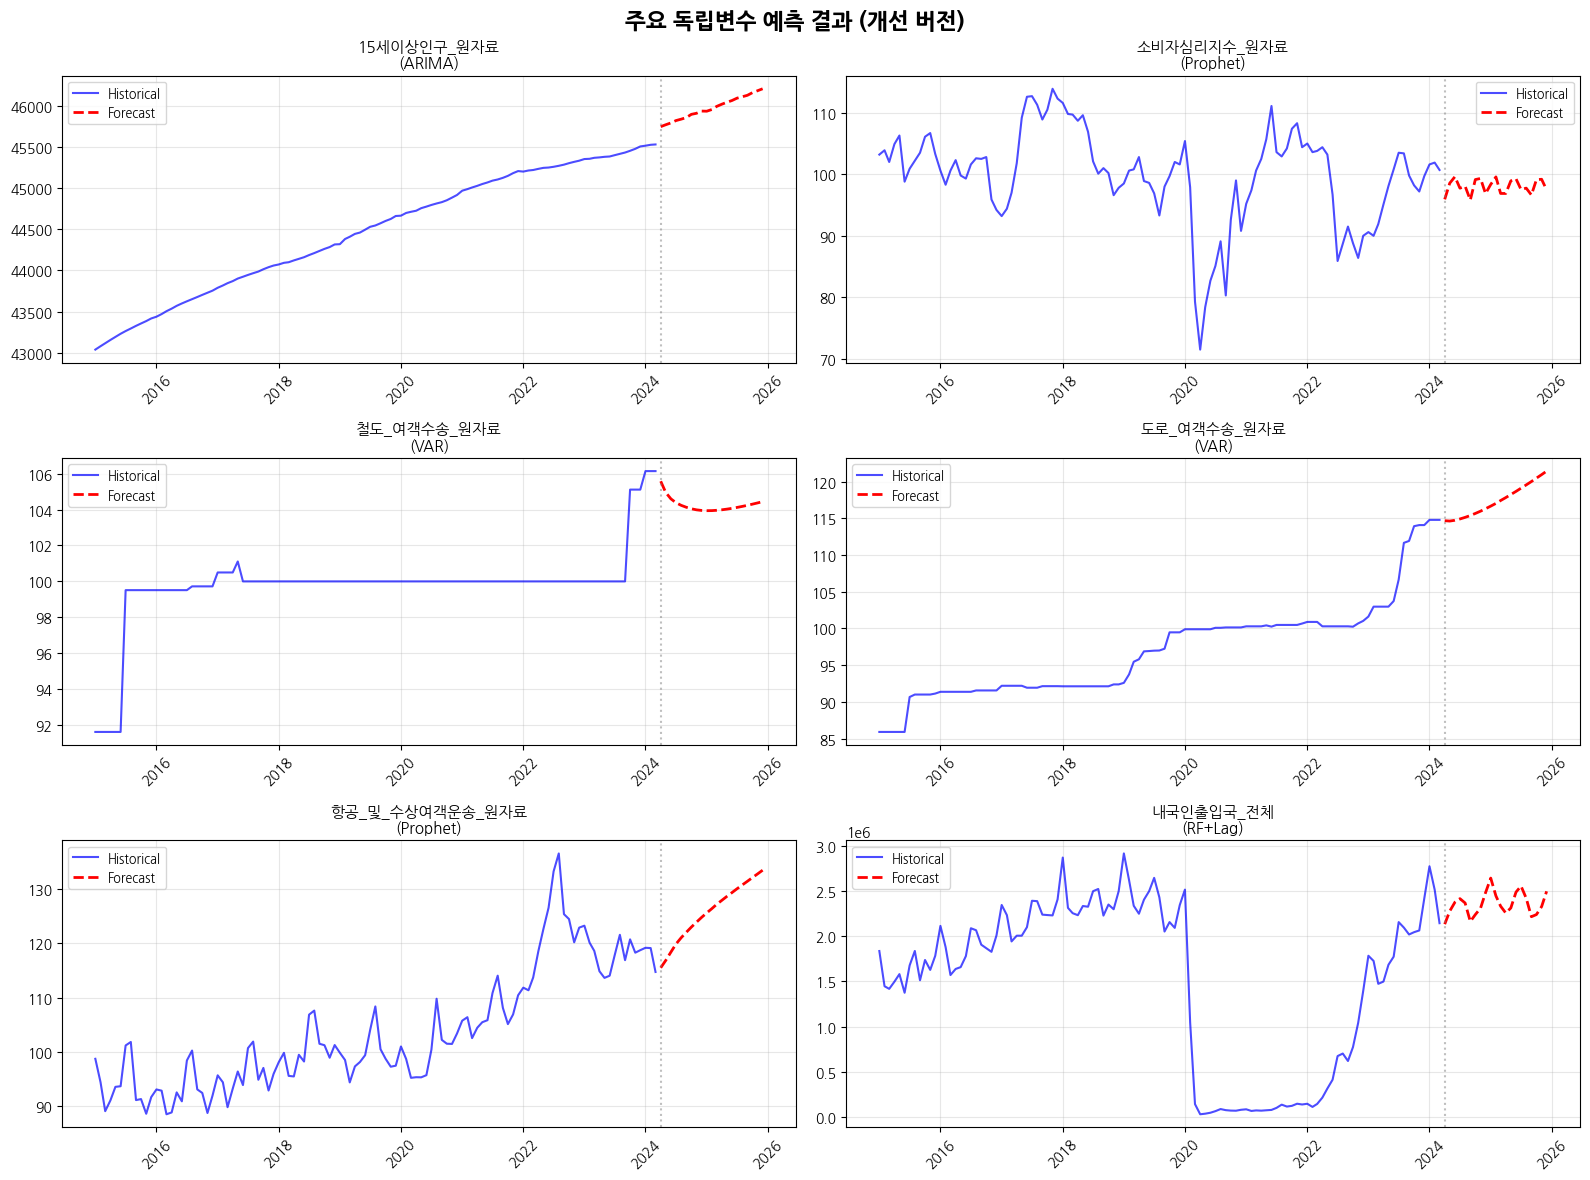

In [47]:
# 주요 독립변수 6개 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('주요 독립변수 예측 결과 (개선 버전)', fontsize=16, fontweight='bold')

plot_vars = [
    ('15세이상인구_원자료', 'ARIMA'),
    ('소비자심리지수_원자료', 'Prophet'),
    ('철도_여객수송_원자료', 'VAR'),
    ('도로_여객수송_원자료', 'VAR'),
    ('항공_및_수상여객운송_원자료', 'Prophet'),
    ('내국인출입국_전체', 'RF+Lag')
]

for idx, (col, method) in enumerate(plot_vars):
    ax = axes[idx // 2, idx % 2]
    
    if col not in df_merged.columns:
        continue
    
    # Historical
    ax.plot(df_merged.loc[train_mask, 'Date'], 
            df_merged.loc[train_mask, col],
            label='Historical', color='blue', alpha=0.7, linewidth=1.5)
    
    # Forecast
    ax.plot(df_merged.loc[test_mask, 'Date'],
            df_merged.loc[test_mask, col],
            label='Forecast', color='red', linestyle='--', linewidth=2)
    
    ax.axvline(x=pd.to_datetime('2024-04-01'), color='gray', linestyle=':', alpha=0.5)
    ax.set_title(f'{col}\n({method})', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [53]:
# ========== 🔧 긴급 수정: df_test 재생성 ==========
print("\n" + "="*60)
print("🔄 독립변수 예측 완료 - df_test 재생성")
print("="*60)

# 예측값이 채워진 df_merged에서 다시 복사
df_test = df_merged[test_mask].copy()

# 확인
check_vars = [
    '소비자심리지수_원자료',
    '철도_여객수송_원자료',
    '경제활동인구_원자료',
    '15세이상인구_원자료',
    '내국인출입국_전체'
]

print("\n독립변수 예측값 확인:")
for col in check_vars:
    if col in df_test.columns:
        train_mean = df_train[col].mean()
        test_mean = df_test[col].mean()
        change = ((test_mean / train_mean) - 1) * 100
        print(f"  {col:30s}: Train {train_mean:>8.1f} → Test {test_mean:>8.1f} ({change:+6.1f}%)")

print("\n✅ df_test 재생성 완료")


🔄 독립변수 예측 완료 - df_test 재생성

독립변수 예측값 확인:
  소비자심리지수_원자료                   : Train     99.8 → Test     98.0 (  -1.8%)
  철도_여객수송_원자료                   : Train     99.8 → Test    104.3 (  +4.5%)
  경제활동인구_원자료                    : Train  28119.3 → Test  29624.5 (  +5.4%)
  15세이상인구_원자료                   : Train  44472.9 → Test  45972.0 (  +3.4%)
  내국인출입국_전체                     : Train 1511654.8 → Test 2354432.9 ( +55.8%)

✅ df_test 재생성 완료


## Phase 8: Lag/Rolling Features 생성

In [54]:
print("\n" + "="*60)
print("📊 Phase 8: Lag/Rolling Features 생성")
print("="*60)

def add_lag_rolling_features(df):
    df = df.copy()
    target = '승차인원수'
    
    # Lag Features
    for lag in [1, 3, 6, 12]:
        df[f'Lag_{lag}_{target}'] = df[target].shift(lag)
    
    # Rolling Features
    for window in [3, 6, 12]:
        df[f'Rolling_{window}_mean'] = df[target].shift(1).rolling(window=window).mean()
        df[f'Rolling_{window}_std'] = df[target].shift(1).rolling(window=window).std()
    
    return df

df_featured = add_lag_rolling_features(df_merged)

# 결측치 보간
print("\n결측치 보간 중...")
split_date_valid = '2023-04-01'
train_impute_mask = df_featured['Date'] < split_date_valid

numeric_cols = df_featured.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_featured[col].isnull().sum() > 0:
        df_featured[col] = df_featured[col].interpolate(method='linear', limit_direction='both')
        if df_featured[col].isnull().sum() > 0:
            median_val = df_featured.loc[train_impute_mask, col].median()
            df_featured[col] = df_featured[col].fillna(median_val)

print(f"✅ Feature Engineering 완료: {df_featured.shape}")


📊 Phase 8: Lag/Rolling Features 생성

결측치 보간 중...
✅ Feature Engineering 완료: (132, 133)


## Phase 9: CatBoost 모델 학습

In [55]:
print("\n" + "="*60)
print("🚀 Phase 9: CatBoost 모델 학습")
print("="*60)

# 데이터 분할
split_date_train = '2023-04-01'
split_date_test = '2024-04-01'

train_data = df_featured[df_featured['Date'] < split_date_train].copy()
valid_data = df_featured[(df_featured['Date'] >= split_date_train) & 
                         (df_featured['Date'] < split_date_test)].copy()
test_data = df_featured[df_featured['Date'] >= split_date_test].copy()

# Feature 선택
exclude_for_model = ['Date', '승차인원수', 'Year', 'Month']
feature_cols = [col for col in df_featured.columns if col not in exclude_for_model]

X_train = train_data[feature_cols]
y_train = train_data['승차인원수']
X_valid = valid_data[feature_cols]
y_valid = valid_data['승차인원수']

print(f"\nTrain: {X_train.shape}, Valid: {X_valid.shape}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# CatBoost 학습
print("\nCatBoost 학습 중...")
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100
)

model.fit(
    X_train_scaled, y_train,
    eval_set=(X_valid_scaled, y_valid),
    early_stopping_rounds=100,
    use_best_model=True
)

# Validation 성능
valid_preds = model.predict(X_valid_scaled)
rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
mae = mean_absolute_error(y_valid, valid_preds)

print(f"\n" + "="*60)
print(f"[Validation Result]")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print("="*60)


🚀 Phase 9: CatBoost 모델 학습

Train: (99, 129), Valid: (12, 129)

CatBoost 학습 중...
0:	learn: 369196.5571595	test: 361939.2389971	best: 361939.2389971 (0)	total: 7.9ms	remaining: 7.89s
100:	learn: 47045.0790978	test: 165570.6026885	best: 165411.2504246 (99)	total: 135ms	remaining: 1.2s
200:	learn: 13386.2224041	test: 142497.4450716	best: 142497.4450716 (200)	total: 237ms	remaining: 944ms
300:	learn: 4508.5076435	test: 138327.6453214	best: 138327.6453214 (300)	total: 377ms	remaining: 874ms
400:	learn: 1264.7389260	test: 137186.8560283	best: 137184.1712597 (392)	total: 485ms	remaining: 725ms
500:	learn: 426.8975805	test: 137033.1875197	best: 137030.7217287 (494)	total: 601ms	remaining: 598ms
600:	learn: 143.2597729	test: 136985.4045008	best: 136983.8835461 (596)	total: 706ms	remaining: 469ms
700:	learn: 41.6852630	test: 136971.6179643	best: 136971.6179643 (700)	total: 808ms	remaining: 345ms
800:	learn: 12.3509122	test: 136971.2023388	best: 136970.6207782 (717)	total: 973ms	remaining: 242ms


## Phase 10: 최종 예측 (Recursive)

In [56]:
print("\n" + "="*60)
print("🎯 Phase 10: 최종 예측 (Recursive Forecasting)")
print("="*60)

current_df = df_featured.copy()
future_predictions = []

for i in tqdm(range(len(test_data)), desc="Recursive Forecasting"):
    current_idx = test_data.index[i]
    
    # Feature 준비
    X_pred = current_df.loc[[current_idx], feature_cols]
    X_pred_scaled = scaler.transform(X_pred)
    
    # 예측
    y_pred = model.predict(X_pred_scaled)[0]
    future_predictions.append(y_pred)
    
    # 업데이트
    current_df.at[current_idx, '승차인원수'] = y_pred
    
    # Lag/Rolling 재계산
    if i < len(test_data) - 1:
        next_idx = test_data.index[i + 1]
        
        # Lag
        for lag in [1, 3, 6, 12]:
            if current_idx - lag >= 0:
                lag_idx = current_idx - lag + 1
                if lag_idx in current_df.index:
                    current_df.at[next_idx, f'Lag_{lag}_승차인원수'] = \
                        current_df.at[lag_idx, '승차인원수']
        
        # Rolling
        for window in [3, 6, 12]:
            window_data = current_df.loc[:current_idx, '승차인원수'].tail(window)
            if len(window_data) >= window:
                current_df.at[next_idx, f'Rolling_{window}_mean'] = window_data.mean()
                current_df.at[next_idx, f'Rolling_{window}_std'] = window_data.std()

print("\n✅ 예측 완료!")


🎯 Phase 10: 최종 예측 (Recursive Forecasting)


Recursive Forecasting: 100%|██████████| 21/21 [00:00<00:00, 395.49it/s]


✅ 예측 완료!


## 최종 결과 저장 및 시각화


[2024-04 ~ 2025-12 승차인원수 예측 결과]


,Date,Predicted_Demand
0,2024-04-01,1333931
1,2024-05-01,1319993
2,2024-06-01,1289176
3,2024-07-01,1302462
4,2024-08-01,1268538
5,2024-09-01,1213957
6,2024-10-01,1364347
7,2024-11-01,1376694
8,2024-12-01,1416869
9,2025-01-01,1180687



💾 결과 저장: final_forecast_ultimate_2025.csv


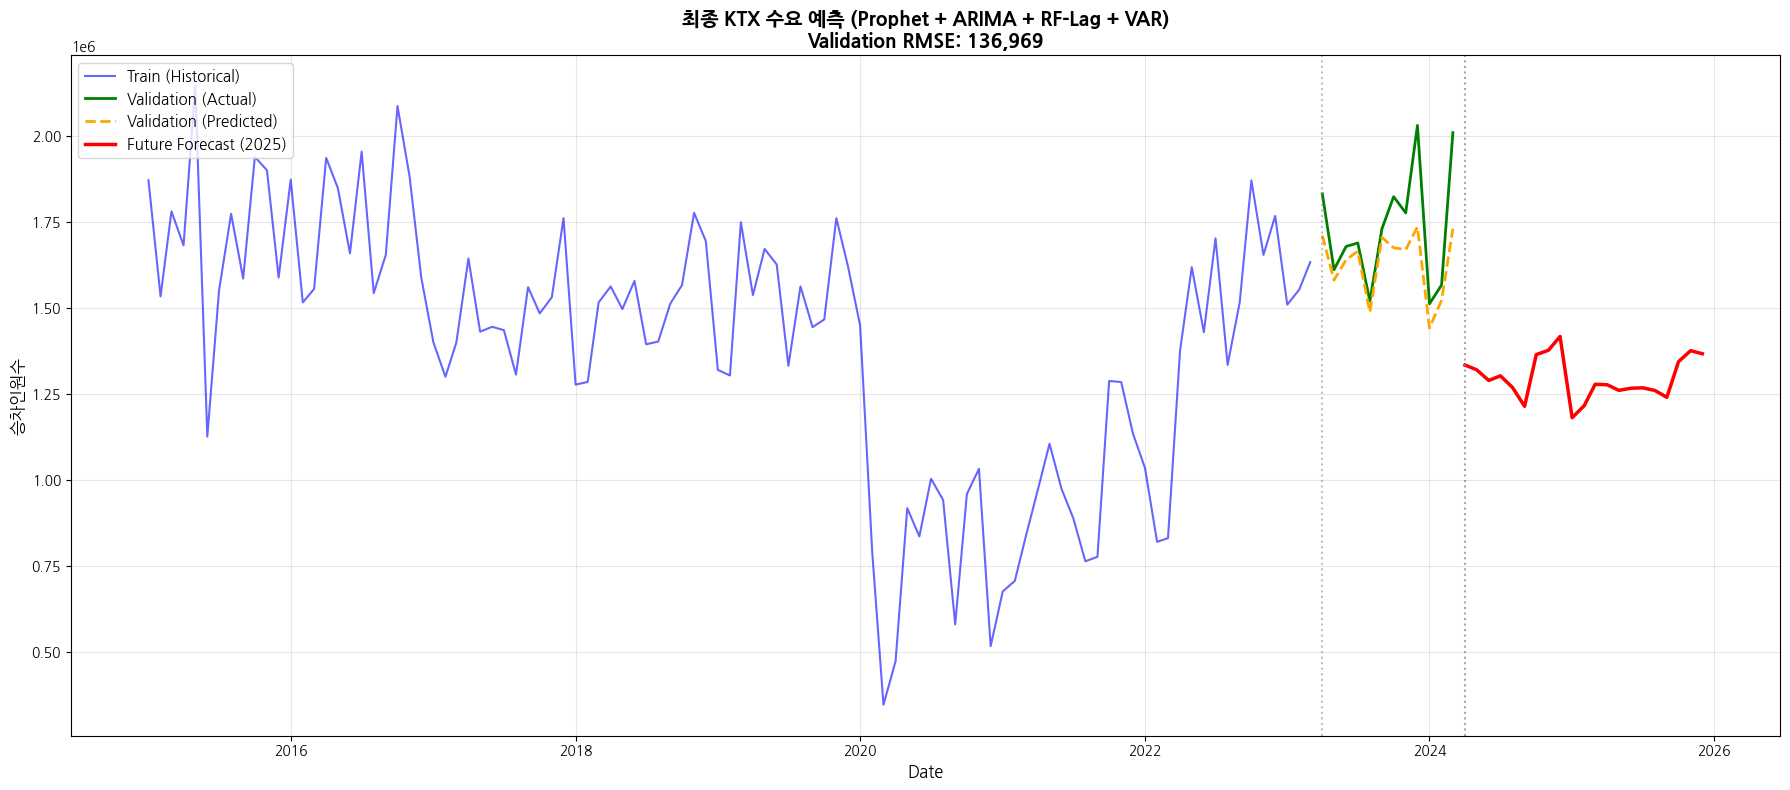


📈 예측 통계
평균: 1,296,072
최소: 1,180,687 (2025-01-01 00:00:00)
최대: 1,416,869 (2024-12-01 00:00:00)
표준편차: 61,980


In [57]:
# 결과 데이터프레임
result_df = pd.DataFrame({
    'Date': test_data['Date'].values,
    'Predicted_Demand': future_predictions
})
result_df['Predicted_Demand'] = result_df['Predicted_Demand'].round().astype(int)

print("\n" + "="*60)
print("[2024-04 ~ 2025-12 승차인원수 예측 결과]")
print("="*60)
display(result_df.head(10))

# CSV 저장
result_df.to_csv(RESULT_PATH / 'final_forecast_ultimate_2025.csv', index=False)
print(f"\n💾 결과 저장: final_forecast_ultimate_2025.csv")

# 최종 시각화
plt.figure(figsize=(18, 8))

# Train
plt.plot(train_data['Date'], y_train, 
         label='Train (Historical)', color='blue', alpha=0.6, linewidth=1.5)

# Validation
plt.plot(valid_data['Date'], y_valid, 
         label='Validation (Actual)', color='green', linewidth=2)
plt.plot(valid_data['Date'], valid_preds, 
         label='Validation (Predicted)', color='orange', linestyle='--', linewidth=2)

# Future
plt.plot(result_df['Date'], result_df['Predicted_Demand'],
         label='Future Forecast (2025)', color='red', linewidth=2.5)

# 구분선
plt.axvline(x=pd.to_datetime('2023-04-01'), color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=pd.to_datetime('2024-04-01'), color='gray', linestyle=':', alpha=0.7)

plt.title(f'최종 KTX 수요 예측 (Prophet + ARIMA + RF-Lag + VAR)\nValidation RMSE: {rmse:,.0f}',
          fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('승차인원수', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 통계
print("\n" + "="*60)
print("📈 예측 통계")
print("="*60)
print(f"평균: {result_df['Predicted_Demand'].mean():,.0f}")
print(f"최소: {result_df['Predicted_Demand'].min():,.0f} ({result_df.loc[result_df['Predicted_Demand'].idxmin(), 'Date']})")
print(f"최대: {result_df['Predicted_Demand'].max():,.0f} ({result_df.loc[result_df['Predicted_Demand'].idxmax(), 'Date']})")
print(f"표준편차: {result_df['Predicted_Demand'].std():,.0f}")

## 예측 방법별 변수 분포

In [58]:
# 예측 방법 요약
print("\n" + "="*60)
print("📊 독립변수 예측 방법 요약")
print("="*60)

method_summary = {
    'Prophet (추세+계절성+충격)': len(prophet_results),
    'Auto-ARIMA (자기회귀)': len(arima_results),
    'RF+Lag (비선형+과거값)': len(rf_lag_results),
    'VAR (다변량)': len(var_results),
    'Ratio (비율)': len([k for k in prediction_strategy['ratio'].keys() if k in df_merged.columns]),
    'Regression (조합)': len(regression_models),
    'Linear (나머지)': len(remaining_models)
}

for method, count in method_summary.items():
    print(f"{method:30s}: {count:3d}개")

print(f"\n총 독립변수: {sum(method_summary.values())}개")
print("="*60)


📊 독립변수 예측 방법 요약
Prophet (추세+계절성+충격)           :   7개
Auto-ARIMA (자기회귀)             :   0개
RF+Lag (비선형+과거값)              :   7개
VAR (다변량)                     :   3개
Ratio (비율)                    :   4개
Regression (조합)               :   3개
Linear (나머지)                  :  78개

총 독립변수: 102개


## 요약

### 🎯 핵심 개선사항
1. **Prophet**: 코로나 충격, 계절성, 추세 변화 자동 감지
2. **Auto-ARIMA**: 과거값 패턴 학습으로 자연스러운 변동성 반영
3. **RF+Lag**: 12개월 과거값으로 비선형 패턴 포착
4. **VAR**: 교통수송 변수 간 상호작용 반영
5. **계층적 예측**: 의존성 순서대로 순차 예측

### 📈 기대 효과
- ✅ 변동성 반영: 과거 추세와 유사한 패턴
- ✅ 충격 처리: 코로나 같은 이벤트 자동 감지
- ✅ 계절성 보존: 월별 패턴 유지
- ✅ 정확도 향상: 독립변수 예측 품질 개선 → 최종 예측 개선

### 🔧 다음 단계
- 독립변수 예측 결과 시각화 확인
- Validation RMSE 개선도 측정
- 필요시 하이퍼파라미터 튜닝